In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

In [ ]:
class SessionGraph:
    """Gestionnaire central du graphe de calcul dynamique (Directed Acyclic Graph)."""

    def __init__(self):
        self.G = nx.DiGraph()
        self.compteur = 0
        self._grad_enabled = True  # Contrôle si on enregistre les opérations ou non

    def set_grad_enabled(self, mode: bool):
        """
        Active ou désactive le suivi des opérations (l'équivalent de torch.no_grad()).
        Très utile pour l'évaluation du modèle sans consommer de mémoire.
        """
        self._grad_enabled = mode

    def add_node(self, noeud):
        """Ajoute un nœud au graphe si le suivi est activé."""
        if not self._grad_enabled:
            return None

        # Gestion d'erreur : on s'assure que l'objet possède bien un nom
        if not hasattr(noeud, 'name'):
            raise AttributeError("L'objet passé au graphe doit posséder un attribut 'name'.")

        id_noeud = f"{noeud.name}_{self.compteur}"
        self.compteur += 1
        self.G.add_node(id_noeud, obj=noeud)
        return id_noeud

    def add_edge(self, parent_id, enfant_id):
        """Crée une connexion (dépendance) entre deux nœuds."""
        if not self._grad_enabled or parent_id is None or enfant_id is None:
            return

        # Gestion d'erreur : vérification de l'intégrité de la topologie
        if not self.G.has_node(parent_id) or not self.G.has_node(enfant_id):
            raise KeyError(f"Tentative de liaison invalide : {parent_id} ou {enfant_id} n'existe pas dans le graphe.")

        self.G.add_edge(parent_id, enfant_id)

    def reset(self):
        """
        Nettoie complètement le graphe en mémoire.
        À appeler IMPÉRATIVEMENT après chaque mise à jour des poids dans la boucle d'entraînement.
        """
        self.G.clear()
        self.compteur = 0

    def show_graph(self, title="Graphe de Calcul (Passe Avant)"):
        """Génère une visualisation de la topologie actuelle du réseau."""
        if self.G.number_of_nodes() == 0:
            print("⚠️ Le graphe est actuellement vide. Rien à afficher.")
            return

        plt.figure(figsize=(10, 6))

        # On récupère les noms propres des nœuds pour l'affichage
        labels = {n: self.G.nodes[n]['obj'].name for n in self.G.nodes}

        # nx.spring_layout est robuste, mais si vous avez un graphe très profond,
        # nx.multipartite_layout ou un layout hiérarchique serait encore mieux.
        pos = nx.spring_layout(self.G, seed=42)

        nx.draw(self.G, pos, with_labels=True, labels=labels,
                node_size=2000, node_color="#A0CBE2",
                font_size=10, font_weight="bold",
                arrowsize=20, edge_color="gray")

        plt.title(title)
        plt.axis('off') # Cache les axes pour plus de propreté
        plt.show()

# On instancie la session globale
session = SessionGraph()

In [ ]:
# ==========================================
# 2. GESTION DU BROADCASTING ET RÈGLES VJP
# ==========================================
def sigmoid(x):
    # f(x) = 1 / (1 + e^-x)
    # np.clip évite l'overflow si x est très négatif
    x_clipped = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x_clipped))

def relu(x):
    # f(x) = max(0, x)
    return np.maximum(0.0, x)

def leaky_relu(x, alpha=0.01):
    # f(x) = x si x > 0, sinon alpha * x
    return np.where(x > 0, x, alpha * x)

# --- Les Avancées (Gradients plus stables) ---
def elu(x, alpha=1.0):
    # f(x) = x si x > 0, sinon alpha * (e^x - 1)
    return np.where(x > 0, x, alpha * (np.exp(x) - 1.0))

def softplus(x):
    # f(x) = ln(1 + e^x) (une version lisse de ReLU)
    x_clipped = np.clip(x, -500, 500)
    return np.log(1.0 + np.exp(x_clipped))

# --- Les Modernes (Transformers, MoE, U-Nets) ---
def swish(x):
    # f(x) = x * sigmoid(x) (très utilisée dans les architectures modernes)
    return x * sigmoid(x)

def gelu(x):
    # f(x) = 0.5 * x * (1 + tanh(sqrt(2/pi) * (x + 0.044715 * x^3)))
    # (Approximation classique de la Gaussian Error Linear Unit)
    const1 = np.sqrt(2.0 / np.pi)
    const2 = 0.044715
    return 0.5 * x * (1.0 + np.tanh(const1 * (x + const2 * np.power(x, 3))))

def softmax(x, axis=-1):
    """Softmax stable numériquement sur le dernier axe (la longueur de séquence)."""
    # On soustrait le max pour éviter l'explosion de l'exponentielle (NaNs)
    x_max = np.max(x, axis=axis, keepdims=True)
    e_x = np.exp(x - x_max)
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

# ==========================================
# OPÉRATIONS DE CONVOLUTION (NumPy Pur)
# ==========================================
def conv2d(x, w):
    """Corrélation croisée 2D 'valid'."""
    h, w_img = x.shape
    fh, fw = w.shape
    out_h = h - fh + 1
    out_w = w_img - fw + 1

    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i, j] = np.sum(x[i:i+fh, j:j+fw] * w)
    return out

def rot180(w):
    """Pivote le filtre de 180 degrés."""
    return np.rot90(w, 2)

def conv2d_full(g, w):
    """Corrélation croisée 2D 'full' pour le calcul du gradient dX."""
    fh, fw = w.shape
    g_padded = np.pad(g, ((fh-1, fh-1), (fw-1, fw-1)), mode='constant')
    return conv2d(g_padded, w)


def _unbroadcast(grad, target_shape):
    """Réduit le gradient à sa forme d'origine si NumPy a fait du broadcasting."""
    if grad.shape == target_shape:
        return grad
    ndims_added = grad.ndim - len(target_shape)
    for _ in range(ndims_added):
        grad = grad.sum(axis=0)
    for i, dim in enumerate(target_shape):
        if dim == 1 and grad.shape[i] > 1:
            grad = grad.sum(axis=i, keepdims=True)
    return grad

# Constante de stabilité numérique
EPSILON = 1e-8

VJP_RULES = {
    # ==========================================
    # 1. OPÉRATIONS BINAIRES (Avec gestion du broadcasting)
    # ==========================================
    np.add:      lambda g, x, y: (_unbroadcast(g, x.shape),
                                  _unbroadcast(g, y.shape)),

    np.subtract: lambda g, x, y: (_unbroadcast(g, x.shape),
                                  _unbroadcast(-g, y.shape)),

    np.multiply: lambda g, x, y: (_unbroadcast(g * y, x.shape),
                                  _unbroadcast(g * x, y.shape)),

    np.divide:   lambda g, x, y: (_unbroadcast(g / y, x.shape),
                                  _unbroadcast(-g * x / (y**2 + EPSILON), y.shape)),

    np.power:    lambda g, x, y: (_unbroadcast(g * y * np.power(x, y - 1), x.shape),
                                  _unbroadcast(g * np.power(x, y) * np.log(x + EPSILON), y.shape)),

    np.maximum:  lambda g, x, y: (_unbroadcast(g * (x >= y), x.shape),
                                  _unbroadcast(g * (x < y), y.shape)),

    # ==========================================
    # 2. OPÉRATIONS UNAIRES (Fonctions d'activation & Math)
    # ==========================================
    np.negative: lambda g, x: (-g,),
    np.square:   lambda g, x: (g * 2 * x,),
    np.sqrt:     lambda g, x: (g / (2 * np.sqrt(x) + EPSILON),),
    np.exp:      lambda g, x: (g * np.exp(x),),
    np.log:      lambda g, x: (g / (x + EPSILON),),

    # Trigonométrie
    np.sin:      lambda g, x: (g * np.cos(x),),
    np.cos:      lambda g, x: (g * -np.sin(x),),

    # Activation non-linéaire (très utile pour les RNN/CNN)
    np.tanh:     lambda g, x: (g * (1 - np.tanh(x)**2),),

    # ==========================================
    # 3. OPÉRATIONS MATRICIELLES
    # ==========================================
    # Le gradient de matmul croise les entrées transposées
    np.matmul:   lambda g, x, y: (np.matmul(g, y.T),
                                  np.matmul(x.T, g)),

    # ==========================================
    # 4. RÉDUCTIONS GLOBALES (Pour la fonction de perte)
    # ==========================================
    # Note: On suppose ici une réduction totale (axis=None).
    # g est donc un scalaire qui sera diffusé par numpy lors de la multiplication.
    np.sum:      lambda g, x: (g * np.ones_like(x),),
    np.mean:     lambda g, x: (g * np.ones_like(x) / np.size(x),),
    # Convolutions
    conv2d: lambda g, x, w: (conv2d_full(g, rot180(w)), conv2d(x, g)),

    # Activations
    sigmoid: lambda g, x: (g * sigmoid(x) * (1.0 - sigmoid(x)),),
    relu: lambda g, x: (g * (x > 0).astype(x.dtype),),
    leaky_relu: lambda g, x: (g * np.where(x > 0, 1.0, 0.01),),
    elu: lambda g, x: (g * np.where(x > 0, 1.0, 1.0 * np.exp(x)),),
    softplus: lambda g, x: (g * sigmoid(x),),
    swish: lambda g, x: (g * (swish(x) + sigmoid(x) * (1.0 - swish(x))),),
    gelu: lambda g, x: (
        g * (0.5 * (1.0 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3))) +
             0.5 * x * (1.0 - np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3))**2) * np.sqrt(2/np.pi) * (1.0 + 3 * 0.044715 * x**2)),
    ),
    softmax: lambda g, x: (
            g * softmax(x) - softmax(x) * np.sum(g * softmax(x), axis=-1, keepdims=True),
        )
}

# ==========================================
# 3. LE TENSEUR (NOTRE NŒUD INTELLIGENT)
# ==========================================

class Tensor(np.ndarray):
    def __new__(cls, input_array, parents=None, op_func=None, name="Var"):
        obj = np.asarray(input_array, dtype=np.float64).view(cls)
        obj.grad = np.zeros_like(obj)
        obj.parents = parents if parents else []
        obj.op_func = op_func
        obj.name = name

        # 1. On inscrit le nouveau nœud dans le graphe
        obj.id = session.add_node(obj)

        # 2. VÉRIFICATION DE SÉCURITÉ POUR LES PARENTS (Le Patch)
        for p in obj.parents:
            # Si le parent est un Tensor persistant qui a été effacé par session.reset(),
            # on le réinscrit silencieusement pour cette nouvelle itération.
            if getattr(p, 'id', None) is None or not session.G.has_node(p.id):
                p.id = session.add_node(p)

            # Maintenant, la liaison est 100% sécurisée
            session.add_edge(p.id, obj.id)

        return obj

    def __array_finalize__(self, obj):
        if obj is None: return

        if hasattr(obj, 'grad'):
            self.grad = obj.grad
        else:
            self.grad = np.zeros(self.shape, dtype=np.float64)

        self.parents = getattr(obj, 'parents', [])
        self.op_func = getattr(obj, 'op_func', None)
        self.name = getattr(obj, 'name', "View")
        self.id = getattr(obj, 'id', None)

    def backward(self, grad_entrant=None):
        if grad_entrant is None:
            grad_entrant = np.ones_like(self)

        self.grad += grad_entrant

        if self.op_func in VJP_RULES and self.parents:
            args_data = [p for p in self.parents]
            gradients_locaux = VJP_RULES[self.op_func](self.grad, *args_data)

            for parent, grad_local in zip(self.parents, gradients_locaux):
                if isinstance(parent, Tensor):
                    parent.backward(grad_local)

# ==========================================
# 4. LE SUPER WRAPPER DYNAMIQUE (Corrigé)
# ==========================================
class DifferentiableNumpy:
    def __init__(self, module_base=np):
        self._module = module_base
        # Dictionnaire des opérations hors-NumPy
        self.custom_ops = {
            'sigmoid': sigmoid,
            'relu': relu,
            'leaky_relu': leaky_relu,
            'elu': elu,
            'softplus': softplus,
            'swish': swish,
            'gelu': gelu,
            'conv2d': conv2d
        }

    def __getattr__(self, nom_fonction):
        # 1. On intercepte d'abord nos fonctions personnalisées
        if nom_fonction in self.custom_ops:
            func_originale = self.custom_ops[nom_fonction]
        # 2. Sinon on laisse NumPy gérer (add, matmul, mean, etc.)
        else:
            func_originale = getattr(self._module, nom_fonction)

        def wrapper_dynamique(*args):
            parents_noeuds = [arg if isinstance(arg, Tensor) else Tensor(arg, name="Cst") for arg in args]
            noeud = Tensor(
                input_array=func_originale(*parents_noeuds),
                parents=parents_noeuds,
                op_func=func_originale,
                name=nom_fonction.capitalize()
            )
            return noeud
        return wrapper_dynamique

dnp = DifferentiableNumpy(np)

class Module:
    """Classe de base pour tous les réseaux de neurones."""
    def __init__(self):
        # Utilisation de __dict__ directement pour éviter de déclencher __setattr__ infiniment
        self.__dict__['_parameters'] = {}
        self.__dict__['_modules'] = {}

    def __setattr__(self, name, value):
        # 1. Si on assigne un Tensor, on l'enregistre comme paramètre
        if isinstance(value, Tensor):
            self._parameters[name] = value
        # 2. Si on assigne un autre Module (ex: une sous-couche), on l'enregistre
        elif isinstance(value, Module):
            self._modules[name] = value

        # Dans tous les cas, on applique l'assignation normale de Python
        super().__setattr__(name, value)

    def parameters(self):
        """Générateur récursif qui renvoie tous les paramètres du module et de ses sous-modules."""
        for param in self._parameters.values():
            yield param
        for module in self._modules.values():
            yield from module.parameters()

    def __call__(self, *args, **kwargs):
        """Permet d'appeler le module comme une fonction : modele(x)."""
        return self.forward(*args, **kwargs)

    def forward(self, *args, **kwargs):
        raise NotImplementedError("La méthode forward doit être redéfinie dans les sous-classes.")

In [ ]:
class Optimizer:
    """Classe de base pour les algorithmes d'optimisation."""
    def __init__(self, parameters, lr=0.01):
        self.parameters = list(parameters)
        self.lr = lr

    def zero_grad(self):
        """Remet à zéro tous les gradients avant la passe arrière."""
        for p in self.parameters:
            if hasattr(p, 'grad'):
                p.grad.fill(0.0)

    def step(self):
        raise NotImplementedError()

class SGD(Optimizer):
    """Descente de Gradient Stochastique classique."""
    def step(self):
        for p in self.parameters:
            if p.grad is not None:
                # W = W - lr * dL/dW
                p[...] = p - self.lr * p.grad

In [ ]:
class CoucheLineaire(Module):
    """Une couche dense standard : Y = X @ W + b"""
    def __init__(self, in_features, out_features, name="Couche"):
        super().__init__()
        # Initialisation de Kaiming/He (idéale pour ReLU)
        std = np.sqrt(2.0 / in_features)
        self.name=name

        # L'assignation déclenche notre __setattr__ personnalisé !
        self.W = Tensor(np.random.randn(in_features, out_features) * std, name=f"{self.name}_Poids")
        self.b = Tensor(np.zeros((1, out_features)), name=f"{self.name}_Biais")

    def forward(self, x):
        # Y = (X @ W) + b
        # (On utilise notre wrapper dnp pour construire le graphe !)
        return dnp.add(dnp.matmul(x, self.W), self.b)

In [ ]:
class Adam(Optimizer):
    """Optimiseur Adam (Adaptative Moment Estimation)."""
    def __init__(self, parameters, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        super().__init__(parameters, lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.t = 0

        # On stocke l'état (les moments) pour chaque paramètre
        # On utilise l'ID de l'objet Python comme clé de dictionnaire
        self.m = {id(p): np.zeros_like(p) for p in self.parameters}
        self.v = {id(p): np.zeros_like(p) for p in self.parameters}

    def step(self):
        self.t += 1
        for p in self.parameters:
            if p.grad is None:
                continue

            pid = id(p)
            grad = p.grad

            # 1. Mise à jour des moments biaisés
            self.m[pid] = self.beta1 * self.m[pid] + (1.0 - self.beta1) * grad
            self.v[pid] = self.beta2 * self.v[pid] + (1.0 - self.beta2) * (grad ** 2)

            # 2. Correction du biais (très important au début de l'entraînement)
            m_hat = self.m[pid] / (1.0 - self.beta1 ** self.t)
            v_hat = self.v[pid] / (1.0 - self.beta2 ** self.t)

            # 3. Mise à jour finale du paramètre
            p[...] = p - self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)

=== Début de l'entraînement du Filtre ===

Époque  50/300 | Perte: 0.309292
Époque 100/300 | Perte: 0.041882
Époque 150/300 | Perte: 0.011498
Époque 200/300 | Perte: 0.007574
Époque 250/300 | Perte: 0.006647
Époque 300/300 | Perte: 0.006098

=== Entraînement Terminé ===

Filtre de Sobel (Vérité) :
 [[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

Filtre Appris (Notre Modèle) :
 [[-1.28 -0.01  1.3 ]
 [-1.49 -0.03  1.51]
 [-1.25  0.03  1.22]]


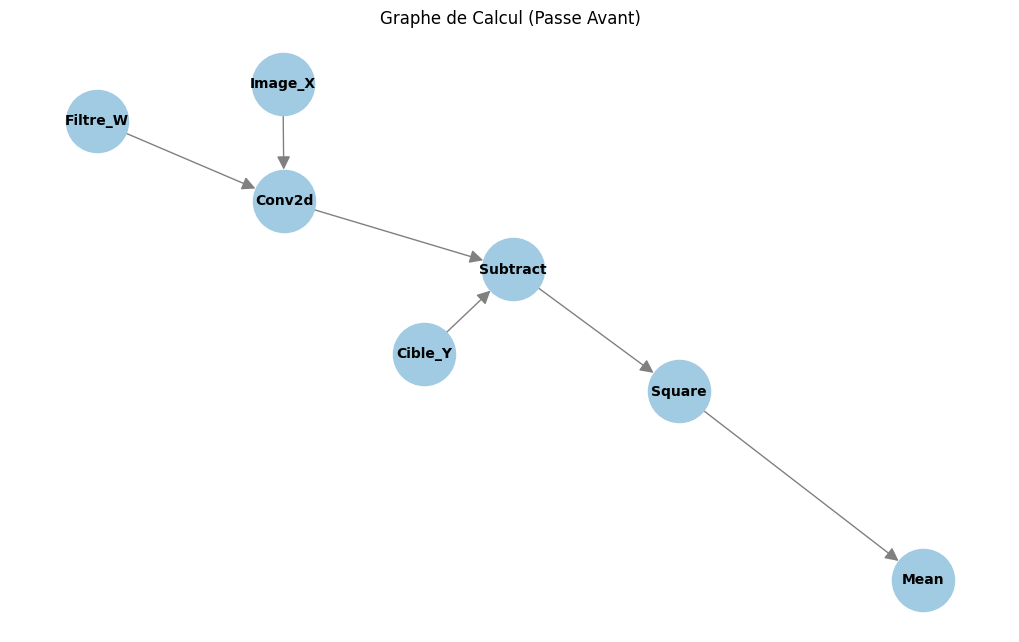

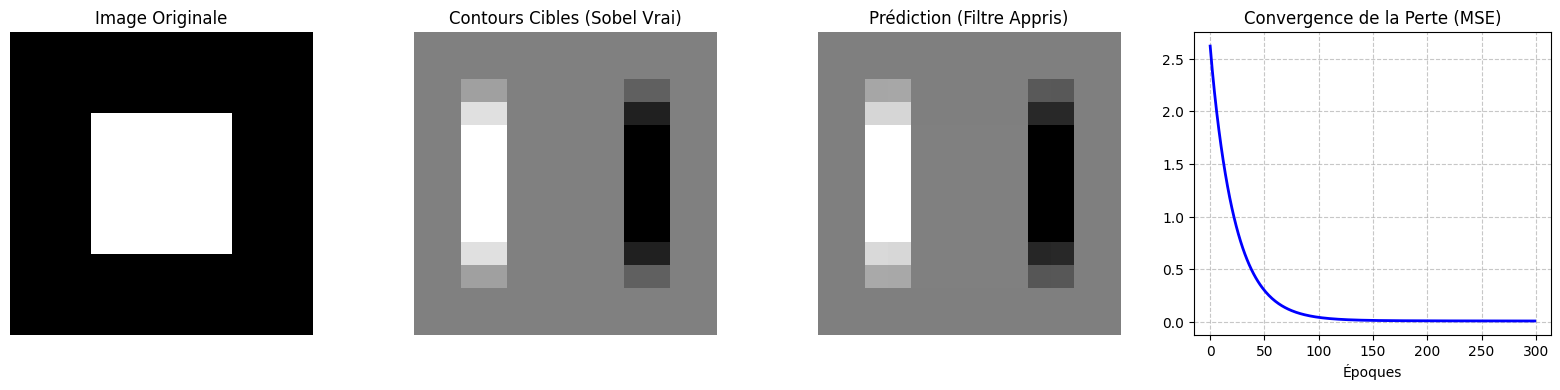

In [ ]:
# ==========================================
# 1. CRÉATION DU SESSION
# ==========================================
session = SessionGraph()

# ==========================================
# 1. CRÉATION DU JEU DE DONNÉES
# ==========================================
# A. L'image d'entrée (15x15) : Un carré blanc au centre
X_img = np.zeros((15, 15))
X_img[4:11, 4:11] = 1.0
X_tensor = Tensor(X_img, name="Image_X")

# B. Le filtre de Sobel Vertical (La vérité terrain que le modèle doit deviner)
W_sobel = np.array([
    [-1.0, 0.0, 1.0],
    [-2.0, 0.0, 2.0],
    [-1.0, 0.0, 1.0]
])

# C. L'image cible (Les vrais contours)
# On utilise la fonction pure de notre dictionnaire pour générer la cible
Y_cible_img = conv2d(X_img, W_sobel)
Y_tensor = Tensor(Y_cible_img, name="Cible_Y")

# ==========================================
# 2. INITIALISATION DU MODÈLE
# ==========================================

# On initialise notre filtre aléatoirement (distribution normale)
np.random.seed(42)
W_appris = Tensor(np.random.randn(3, 3) * 0.1, name="Filtre_W")

epochs = 300
learning_rate = 0.05
historique_loss = []

print("=== Début de l'entraînement du Filtre ===\n")

# ==========================================
# 3. BOUCLE D'ENTRAÎNEMENT (SGD)
# ==========================================

for epoch in range(epochs):
    # 0. Nettoyage vital du graphe (pour ne pas exploser la RAM)
    session.reset()

    # 1. PASSE AVANT
    # pred = conv2d(X, W)
    pred = dnp.conv2d(X_tensor, W_appris)

    # Calcul de la MSE : Loss = mean((pred - Y_cible)^2)
    diff = dnp.subtract(pred, Y_tensor)
    diff_sq = dnp.square(diff)
    loss = dnp.mean(diff_sq)

    # 2. PASSE ARRIÈRE
    # Remise à zéro stricte des gradients du filtre
    W_appris.grad.fill(0.0)

    # Rétropropagation
    loss.backward()

    # 3. MISE À JOUR (Descente de Gradient)
    # W = W - lr * dL/dW
    W_appris[...] = W_appris - learning_rate * W_appris.grad

    historique_loss.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Époque {epoch+1:3d}/{epochs} | Perte: {loss.item():.6f}")

print("\n=== Entraînement Terminé ===")
print("\nFiltre de Sobel (Vérité) :\n", W_sobel)
print("\nFiltre Appris (Notre Modèle) :\n", np.round(W_appris.data, 2))

session.show_graph()

# ==========================================
# 4. VISUALISATION DES RÉSULTATS
# ==========================================

plt.figure(figsize=(16, 4))

# 1. L'image originale
plt.subplot(1, 4, 1)
plt.imshow(X_img, cmap='gray')
plt.title("Image Originale")
plt.axis('off')

# 2. La cible (Contours parfaits)
plt.subplot(1, 4, 2)
plt.imshow(Y_cible_img, cmap='gray')
plt.title("Contours Cibles (Sobel Vrai)")
plt.axis('off')

# 3. La prédiction finale de notre filtre appris
plt.subplot(1, 4, 3)
plt.imshow(pred.data, cmap='gray')
plt.title("Prédiction (Filtre Appris)")
plt.axis('off')

# 4. Courbe de perte
plt.subplot(1, 4, 4)
plt.plot(historique_loss, color='blue', lw=2)
plt.title("Convergence de la Perte (MSE)")
plt.xlabel("Époques")
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

=== Entraînement sur XOR ===
Époque  40/200 | Perte: 0.0129
Époque  80/200 | Perte: 0.0030
Époque 120/200 | Perte: 0.0016
Époque 160/200 | Perte: 0.0011
Époque 200/200 | Perte: 0.0008

Prédictions Finales (Proches de 0 ou 1) :
[[0.049]
 [0.989]
 [0.984]
 [0.016]]


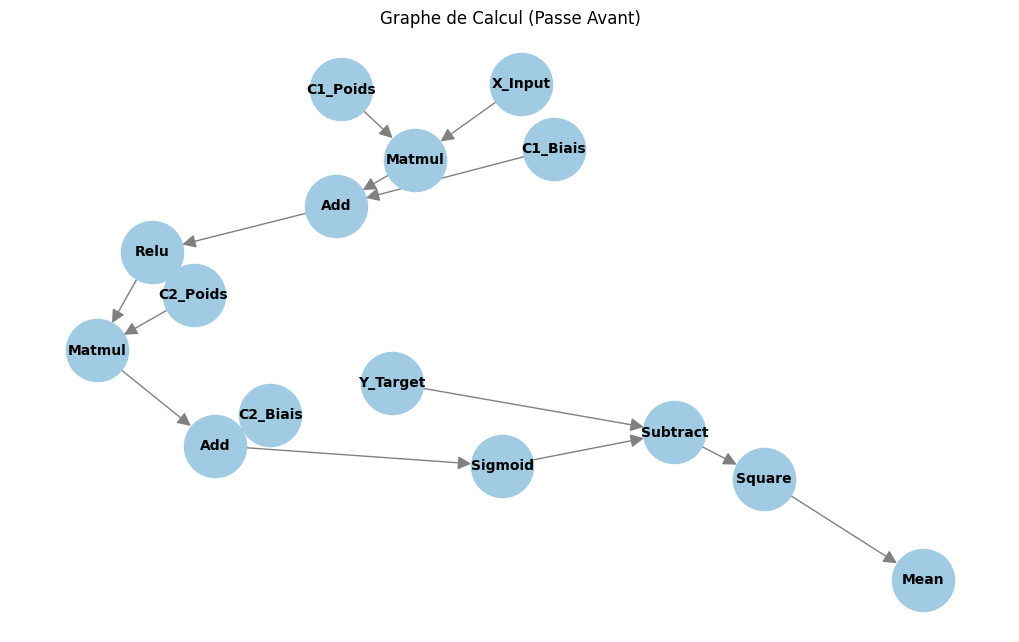

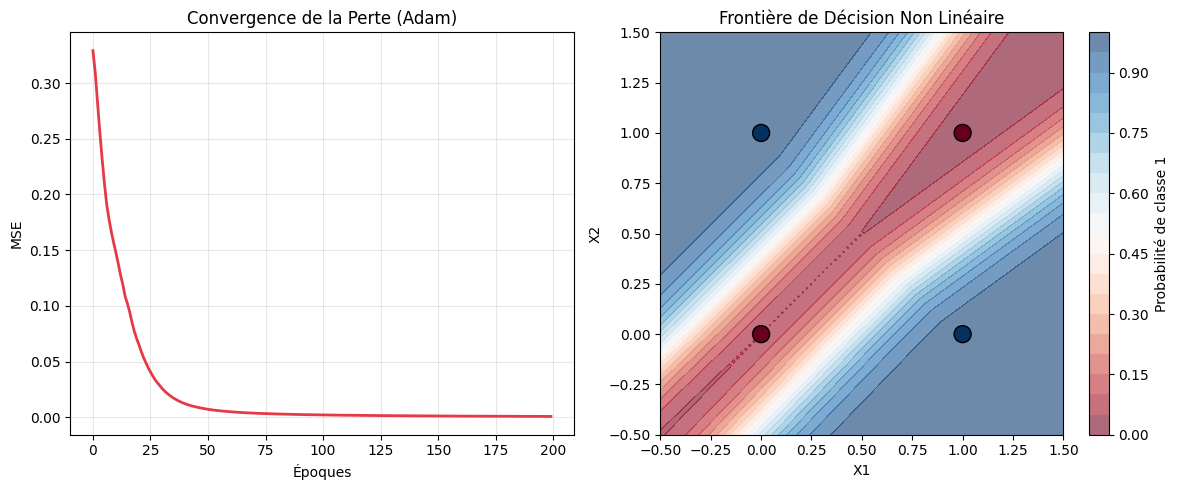

In [ ]:
# ==========================================
# 4. LE PROBLÈME XOR
# ==========================================
# Le dataset XOR
session = SessionGraph()
X_data = Tensor(np.array([[0,0], [0,1], [1,0], [1,1]]), name="X_Input")
Y_data = Tensor(np.array([[0], [1], [1], [0]]), name="Y_Target")

# Notre Réseau : 2 entrées -> 8 neurones cachés (ReLU) -> 1 sortie (Sigmoïde)
class ReseauXOR(Module):
    def __init__(self):
        super().__init__()
        self.c1 = CoucheLineaire(2, 8, name="C1")
        self.c2 = CoucheLineaire(8, 1, name="C2")

    def forward(self, x):
        h = self.c1(x)
        h_relu = dnp.relu(h)
        out = self.c2(h_relu)
        return dnp.sigmoid(out)

np.random.seed(42)
modele = ReseauXOR()
optimiseur = Adam(modele.parameters(), lr=0.05)

print("=== Entraînement sur XOR ===")
historique_loss = []
epochs = 200

for epoch in range(epochs):
    session.reset()
    optimiseur.zero_grad()

    # 1. Forward
    pred = modele(X_data)

    # 2. Loss (MSE pour simplifier)
    diff = dnp.subtract(pred, Y_data)
    loss = dnp.mean(dnp.square(diff))

    # 3. Backward
    loss.backward()

    # 4. Optimize
    optimiseur.step()

    historique_loss.append(loss.item())
    if (epoch+1) % 40 == 0:
        print(f"Époque {epoch+1:3d}/{epochs} | Perte: {loss.item():.4f}")

print("\nPrédictions Finales (Proches de 0 ou 1) :")
print(np.round(pred.data, 3))

# ==========================================
# 5. VISUALISATION DE LA FRONTIÈRE DE DÉCISION
# ==========================================
session.show_graph()


plt.figure(figsize=(12, 5))

# Graphique de la Loss
plt.subplot(1, 2, 1)
plt.plot(historique_loss, color='#E63946', lw=2)
plt.title("Convergence de la Perte (Adam)")
plt.xlabel("Époques")
plt.ylabel("MSE")
plt.grid(True, alpha=0.3)

# Graphique de la Frontière de décision
plt.subplot(1, 2, 2)
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
grille = np.c_[xx.ravel(), yy.ravel()]

# On désactive le graphe pour l'inférence afin d'économiser la RAM
session.reset()

# --- LA CORRECTION EST ICI ---
# 1. On fait la passe avant pour obtenir un Tensor
Z_tensor = modele(Tensor(grille, name="Grille"))

# 2. On convertit proprement le Tensor en ndarray standard avec np.asarray()
Z = np.asarray(Z_tensor).reshape(xx.shape)
# -----------------------------

plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
plt.colorbar(label="Probabilité de classe 1")

# On superpose nos 4 points XOR
# (Même logique ici, np.asarray est plus sûr que .data)
X_numpy = np.asarray(X_data)
Y_numpy = np.asarray(Y_data)

plt.scatter(X_numpy[:, 0], X_numpy[:, 1], c=Y_numpy.flatten(),
            cmap='RdBu', edgecolors='k', s=150, zorder=3)

plt.title("Frontière de Décision Non Linéaire")
plt.xlabel("X1")
plt.ylabel("X2")
plt.tight_layout()
plt.show()